# Módulo 1 — Análise exploratória e preparação dos dados

Este notebook corresponde ao Módulo 1 do projeto. O objetivo é selecionar e contextualizar o conjunto de dados, caracterizar e limpar os dados, realizar análise univariada e bivariada, construir a matriz de correlação, analisar valores em falta e potenciais anomalias, e preparar os dados para a divisão entre treino e teste.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

DATA_PATH = Path("../data/diabetic_data.csv")

df = pd.read_csv(DATA_PATH)

df.shape

(101766, 50)

## 1.1 Seleção e contextualização do conjunto de dados

O conjunto de dados utilizado neste projeto é o `diabetic_data.csv`, relativo a episódios hospitalares de pacientes com diabetes.

O objetivo do projeto é estudar a possibilidade de prever a readmissão hospitalar em menos de 30 dias, utilizando variáveis demográficas, clínicas e administrativas. Esta previsão é relevante porque a readmissão precoce pode indicar maior risco clínico, necessidade de melhor acompanhamento após a alta e impacto acrescido nos recursos hospitalares.

A variável-alvo original é `readmitted`, que indica se o paciente foi readmitido no hospital. Esta variável contém três categorias: `NO`, `>30` e `<30`.

Neste projeto, será criada posteriormente uma variável binária denominada `readmitted_30`, onde a classe positiva corresponde aos pacientes readmitidos em menos de 30 dias.

In [41]:
# Caracterização inicial do conjunto de dados

print("Dimensão do dataset:")
print(df.shape)

print("\nPrimeiras linhas:")
display(df.head())

print("\nInformação geral:")
df.info()

Dimensão do dataset:
(101766, 50)

Primeiras linhas:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO



Informação geral:
<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medicati

In [42]:
# Lista de colunas

df.columns.tolist()

['encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'weight',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'payer_code',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'readmitted']

In [43]:
# Tipos de dados

df.dtypes.value_counts()

str      37
int64    13
Name: count, dtype: int64

## 1.3 Análise da variável-alvo original

A variável-alvo original é `readmitted`. Esta variável indica se o paciente foi readmitido no hospital após a alta.

As categorias existentes são:

- `NO`: paciente não readmitido;
- `>30`: paciente readmitido após mais de 30 dias;
- `<30`: paciente readmitido em menos de 30 dias.

Nesta fase, é analisada a distribuição original desta variável antes da criação da variável binária para modelação.

In [44]:
# Frequências absolutas e relativas da variável-alvo original

target_counts = df["readmitted"].value_counts()
target_pct = df["readmitted"].value_counts(normalize=True) * 100

target_distribution = pd.DataFrame({
    "n": target_counts,
    "percentagem": target_pct
})

target_distribution

,n,percentagem
readmitted,,
NO,54864,53.911916
>30,35545,34.928169
<30,11357,11.159916


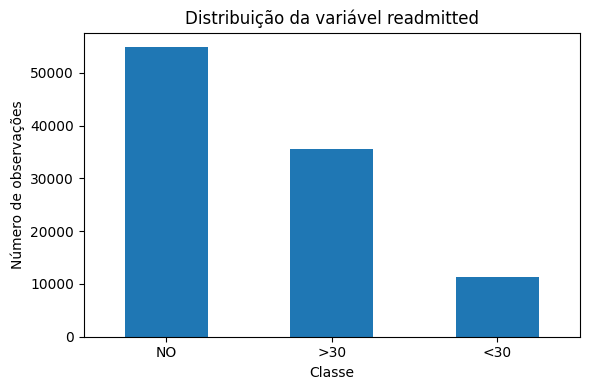

In [45]:
# Gráfico da distribuição da variável-alvo original

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")

plt.title("Distribuição da variável readmitted")
plt.xlabel("Classe")
plt.ylabel("Número de observações")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../outputs/figuras/distribuicao_readmitted.png", dpi=300, bbox_inches="tight")
plt.show()

## 1.4 Criação da variável-alvo binária

Para efeitos de modelação, a variável original `readmitted` foi transformada numa variável binária denominada `readmitted_30`.

A classe positiva, codificada como `1`, corresponde aos pacientes readmitidos em menos de 30 dias (`<30`). A classe negativa, codificada como `0`, inclui os pacientes não readmitidos (`NO`) e os pacientes readmitidos após mais de 30 dias (`>30`).

Esta transformação permite focar o projeto na previsão da readmissão precoce, considerada mais relevante do ponto de vista clínico e organizacional.

In [46]:
df["readmitted_30"] = np.where(df["readmitted"] == "<30", 1, 0)

readmitted_30_counts = df["readmitted_30"].value_counts()
readmitted_30_pct = df["readmitted_30"].value_counts(normalize=True) * 100

readmitted_30_distribution = pd.DataFrame({
    "n": readmitted_30_counts,
    "percentagem": readmitted_30_pct
})

readmitted_30_distribution

,n,percentagem
readmitted_30,,
0,90409,88.840084
1,11357,11.159916


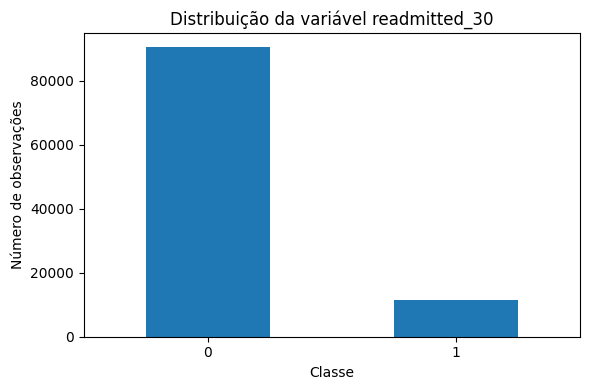

In [47]:
plt.figure(figsize=(6, 4))
readmitted_30_counts.plot(kind="bar")

plt.title("Distribuição da variável readmitted_30")
plt.xlabel("Classe")
plt.ylabel("Número de observações")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../outputs/figuras/distribuicao_readmitted_30.png", dpi=300, bbox_inches="tight")
plt.show()

## 1.5 Tratamento de valores em falta

Nesta etapa, os valores representados por `?` são convertidos em valores em falta reais (`NaN`). Em seguida, é calculada a quantidade e a percentagem de valores em falta por variável.

Esta análise permite identificar variáveis com elevada ausência de informação e definir uma estratégia de tratamento adequada antes das fases seguintes de análise e modelação.

In [48]:
# Substituir "?" por valores em falta reais
df_missing = df.replace("?", np.nan)

# Tabela de valores em falta
missing_table = pd.DataFrame({
    "n_missing": df_missing.isna().sum(),
    "pct_missing": df_missing.isna().mean() * 100
}).sort_values("pct_missing", ascending=False)

missing_table[missing_table["n_missing"] > 0]

,n_missing,pct_missing
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


## 1.6 Limpeza inicial dos dados

Com base na análise de valores em falta, foram removidas variáveis com ausência muito elevada ou com utilidade limitada para esta primeira abordagem exploratória.

A variável `weight` foi removida devido à sua percentagem muito elevada de valores em falta. As variáveis `payer_code` e `medical_specialty` também foram removidas nesta fase, por apresentarem elevada ausência de informação e por poderem introduzir complexidade adicional na análise.

As variáveis `max_glu_serum` e `A1Cresult` foram mantidas, apesar da elevada ausência de valores, porque a ausência destes resultados pode representar informação clínica relevante, nomeadamente a não realização desses testes. Os valores em falta nestas variáveis foram preenchidos com a categoria `Unknown`.

As restantes variáveis com baixa percentagem de valores em falta foram igualmente preenchidas com `Unknown`.

In [49]:
# Criar cópia limpa do dataset
df_clean = df_missing.copy()

# Remover colunas com elevada ausência ou menor utilidade nesta fase
cols_to_drop = [
    "weight",
    "payer_code",
    "medical_specialty"
]

df_clean = df_clean.drop(columns=cols_to_drop)

# Preencher valores em falta das variáveis mantidas
cols_fill_unknown = [
    "race",
    "diag_1",
    "diag_2",
    "diag_3",
    "max_glu_serum",
    "A1Cresult"
]

for col in cols_fill_unknown:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna("Unknown")

# Verificar dimensão após limpeza
df_clean.shape

(101766, 48)

In [50]:
# Confirmar se ainda existem valores em falta
missing_after_cleaning = pd.DataFrame({
    "n_missing": df_clean.isna().sum(),
    "pct_missing": df_clean.isna().mean() * 100
}).sort_values("pct_missing", ascending=False)

missing_after_cleaning[missing_after_cleaning["n_missing"] > 0]

,n_missing,pct_missing


In [51]:
df_clean.shape


(101766, 48)

## 1.7 Análise univariada das variáveis numéricas

Nesta etapa são analisadas individualmente algumas variáveis numéricas relevantes. O objetivo é compreender a sua distribuição, escala, valores mínimos e máximos, e identificar padrões iniciais nos dados.

In [52]:
numeric_vars = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

df_clean[numeric_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.339730,1.705807,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0
number_diagnoses,101766.0,7.422607,1.933600,1.0,6.0,8.0,9.0,16.0


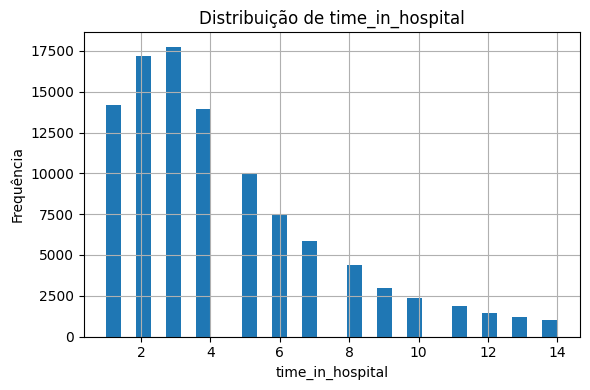

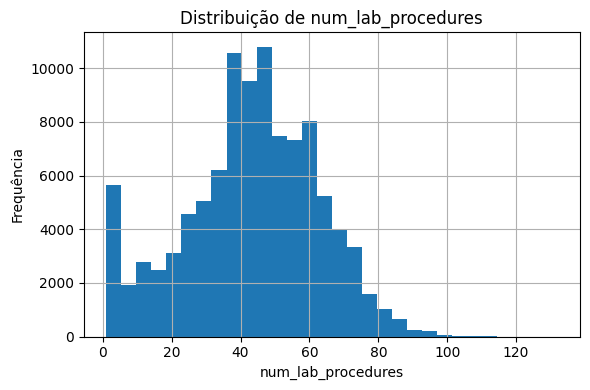

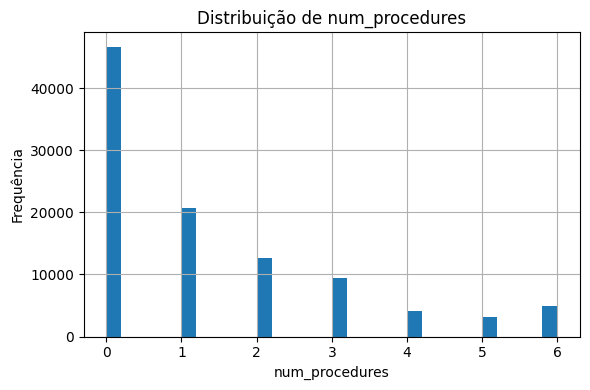

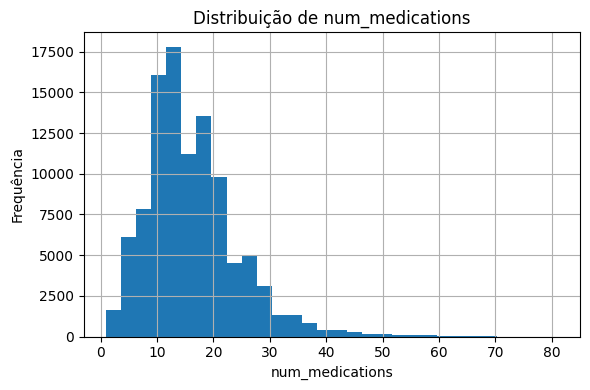

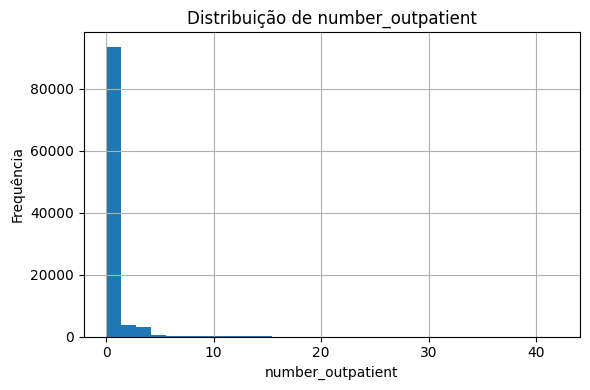

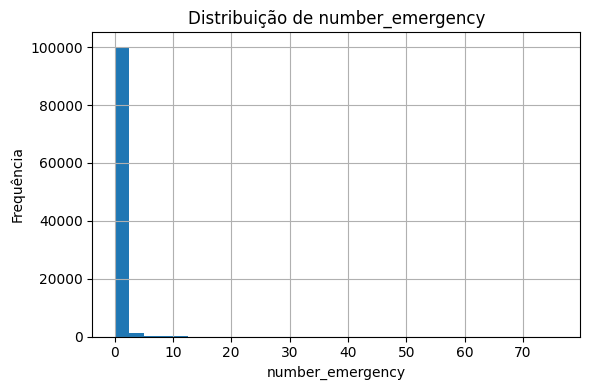

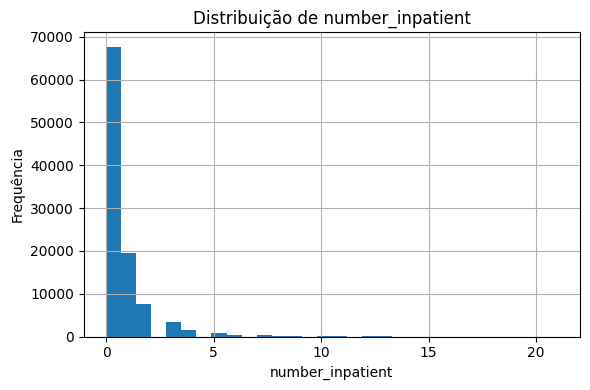

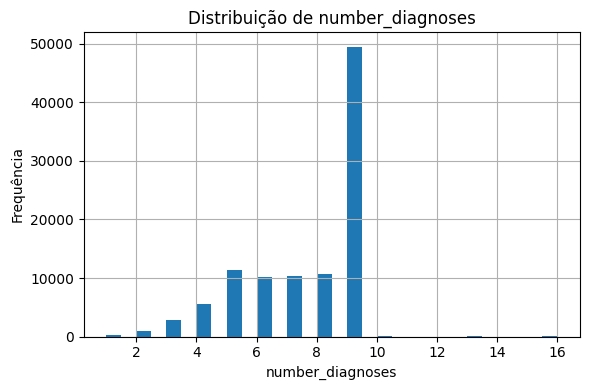

In [53]:
# Histogramas das variáveis numéricas selecionadas

for col in numeric_vars:
    plt.figure(figsize=(6, 4))
    df_clean[col].hist(bins=30)
    
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.tight_layout()
    
    plt.savefig(f"../outputs/figuras/hist_{col}.png", dpi=300, bbox_inches="tight")
    plt.show()

## 1.8 Análise univariada das variáveis categóricas

Nesta etapa são analisadas algumas variáveis categóricas relevantes, com o objetivo de compreender a distribuição das principais categorias e identificar possíveis desequilíbrios.

In [54]:
categorical_vars = [
    "race",
    "gender",
    "age",
    "max_glu_serum",
    "A1Cresult",
    "change",
    "diabetesMed"
]

for col in categorical_vars:
    print(f"\nVariável: {col}")
    display(df_clean[col].value_counts(dropna=False).head(10))


Variável: race


race
Caucasian          76099
AfricanAmerican    19210
Unknown             2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64


Variável: gender


gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


Variável: age


...

A1Cresult
Unknown    84748
>8          8216
Norm        4990
>7          3812
Name: count, dtype: int64


Variável: change


change
No    54755
Ch    47011
Name: count, dtype: int64


Variável: diabetesMed


diabetesMed
Yes    78363
No     23403
Name: count, dtype: int64

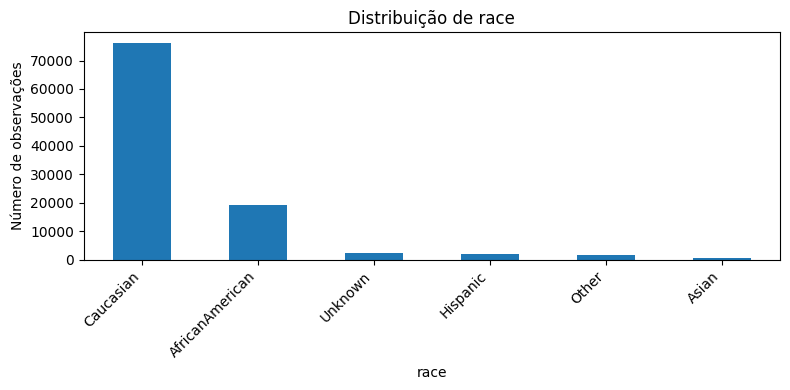

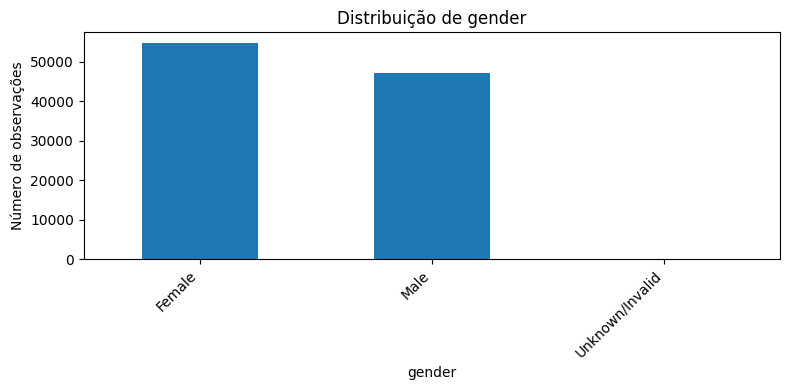

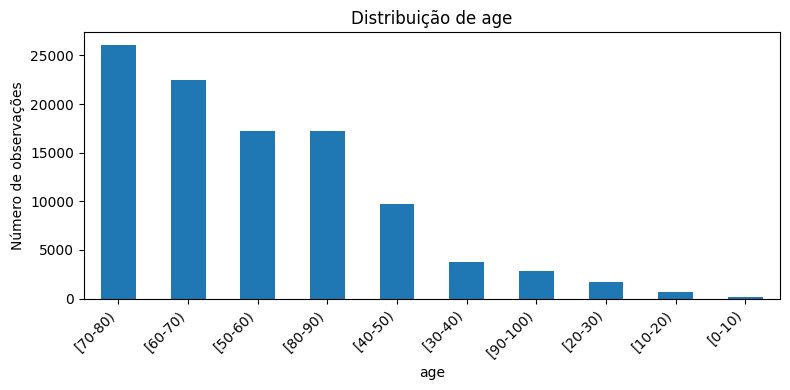

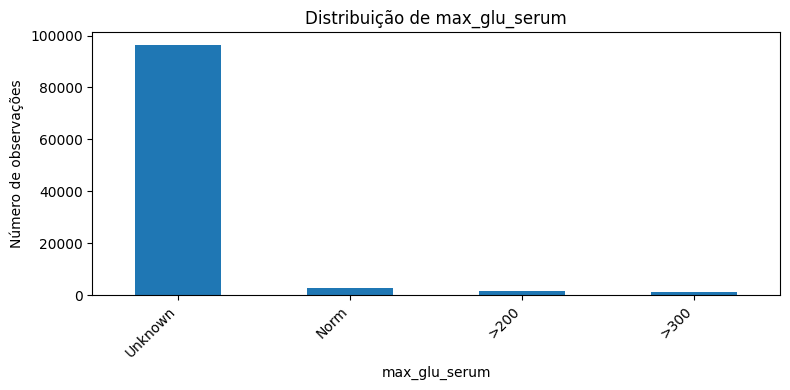

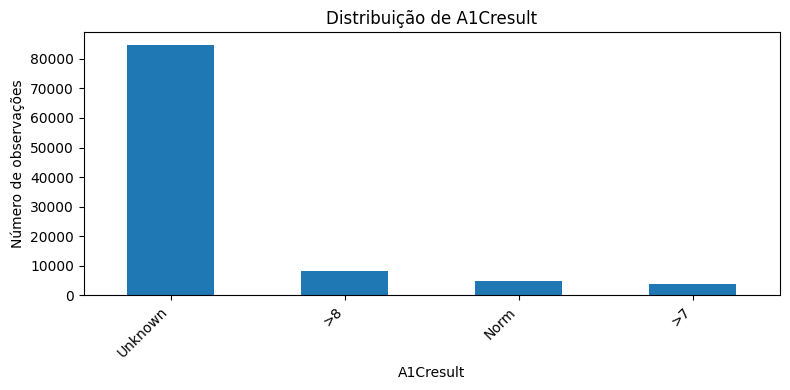

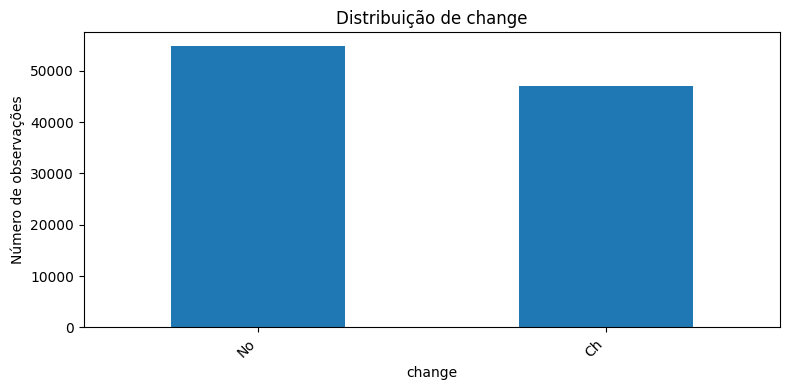

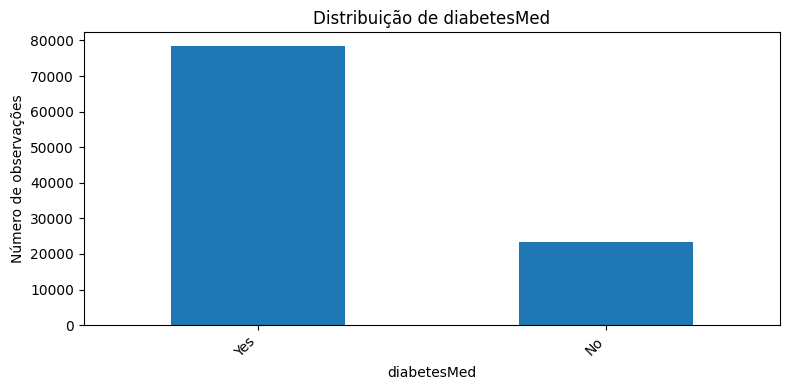

In [55]:
for col in categorical_vars:
    counts = df_clean[col].value_counts(dropna=False).head(10)

    plt.figure(figsize=(8, 4))
    counts.plot(kind="bar")

    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Número de observações")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    plt.savefig(f"../outputs/figuras/bar_{col}.png", dpi=300, bbox_inches="tight")
    plt.show()

## 1.9 Análise bivariada com a variável-alvo

Nesta etapa são analisadas relações entre algumas variáveis explicativas e a variável-alvo binária `readmitted_30`.

O objetivo é perceber se existem diferenças relevantes entre os pacientes readmitidos em menos de 30 dias e os restantes pacientes, tanto em variáveis numéricas como em variáveis categóricas.

In [56]:
# Médias das variáveis numéricas por classe da variável-alvo

bivariate_numeric = df_clean.groupby("readmitted_30")[numeric_vars].mean().T

bivariate_numeric

readmitted_30,0,1
time_in_hospital,4.349224,4.768249
num_lab_procedures,42.953644,44.226028
num_procedures,1.347123,1.280884
num_medications,15.911137,16.903143
number_outpatient,0.360871,0.436911
number_emergency,0.177803,0.357313
number_inpatient,0.561648,1.224003
number_diagnoses,7.388667,7.692789


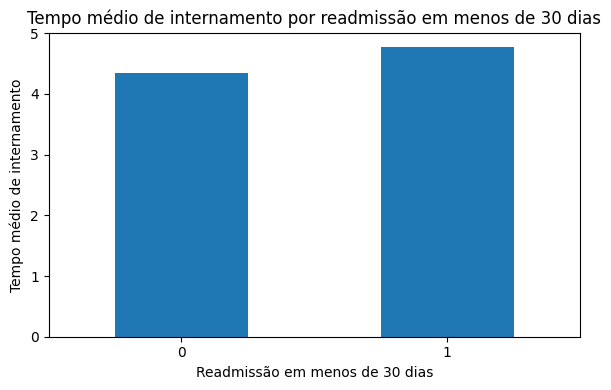

In [57]:
plt.figure(figsize=(6, 4))

df_clean.groupby("readmitted_30")["time_in_hospital"].mean().plot(kind="bar")

plt.title("Tempo médio de internamento por readmissão em menos de 30 dias")
plt.xlabel("Readmissão em menos de 30 dias")
plt.ylabel("Tempo médio de internamento")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../outputs/figuras/time_in_hospital_por_readmitted_30.png", dpi=300, bbox_inches="tight")
plt.show()

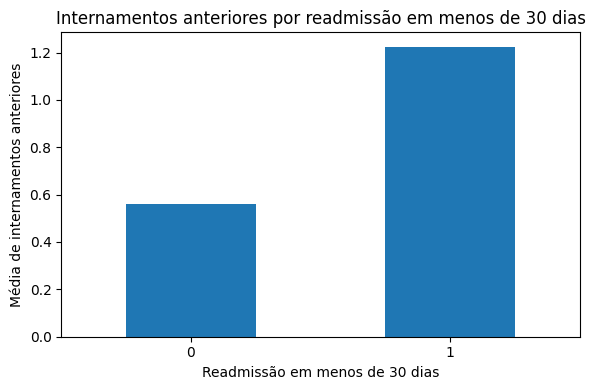

In [58]:
plt.figure(figsize=(6, 4))

df_clean.groupby("readmitted_30")["number_inpatient"].mean().plot(kind="bar")

plt.title("Internamentos anteriores por readmissão em menos de 30 dias")
plt.xlabel("Readmissão em menos de 30 dias")
plt.ylabel("Média de internamentos anteriores")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../outputs/figuras/number_inpatient_por_readmitted_30.png", dpi=300, bbox_inches="tight")
plt.show()

## 1.10 Matriz de correlação

Nesta etapa é calculada a matriz de correlação entre as variáveis numéricas. O objetivo é identificar relações lineares entre variáveis e perceber quais apresentam maior associação com a variável-alvo `readmitted_30`.

A matriz de correlação é aplicada apenas a variáveis numéricas. As variáveis categóricas não são incluídas nesta análise sem codificação prévia.

In [60]:
# Selecionar variáveis numéricas para matriz de correlação
numeric_corr_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Remover identificadores, se existirem
cols_to_remove_corr = ["encounter_id", "patient_nbr"]

numeric_corr_cols = [
    col for col in numeric_corr_cols 
    if col not in cols_to_remove_corr
]

corr_matrix = df_clean[numeric_corr_cols].corr()

corr_matrix

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted_30
admission_type_id,1.000000,0.083483,0.106654,-0.012500,-0.143713,0.129888,0.079535,0.026511,-0.019116,-0.038161,-0.117126,-0.011651
discharge_disposition_id,0.083483,1.000000,0.018193,0.162748,0.023415,0.015921,0.108753,-0.008715,-0.024471,0.020787,0.046891,0.050560
admission_source_id,0.106654,0.018193,1.000000,-0.006965,0.048885,-0.135400,-0.054533,0.027244,0.059892,0.036314,0.072114,0.005820
time_in_hospital,-0.012500,0.162748,-0.006965,1.000000,0.318450,0.191472,0.466135,-0.008916,-0.009681,0.073623,0.220186,0.044199
num_lab_procedures,-0.143713,0.023415,0.048885,0.318450,1.000000,0.058066,0.268161,-0.007602,-0.002279,0.039231,0.152773,0.020364
num_procedures,0.129888,0.015921,-0.135400,0.191472,0.058066,1.000000,0.385767,-0.024819,-0.038179,-0.066236,0.073734,-0.012227
num_medications,0.079535,0.108753,-0.054533,0.466135,0.268161,0.385767,1.000000,0.045197,0.013180,0.064194,0.261526,0.038432
number_outpatient,0.026511,-0.008715,0.027244,-0.008916,-0.007602,-0.024819,0.045197,1.000000,0.091459,0.107338,0.094152,0.018893
number_emergency,-0.019116,-0.024471,0.059892,-0.009681,-0.002279,-0.038179,0.013180,0.091459,1.000000,0.266559,0.055539,0.060747
number_inpatient,-0.038161,0.020787,0.036314,0.073623,0.039231,-0.066236,0.064194,0.107338,0.266559,1.000000,0.104710,0.165147


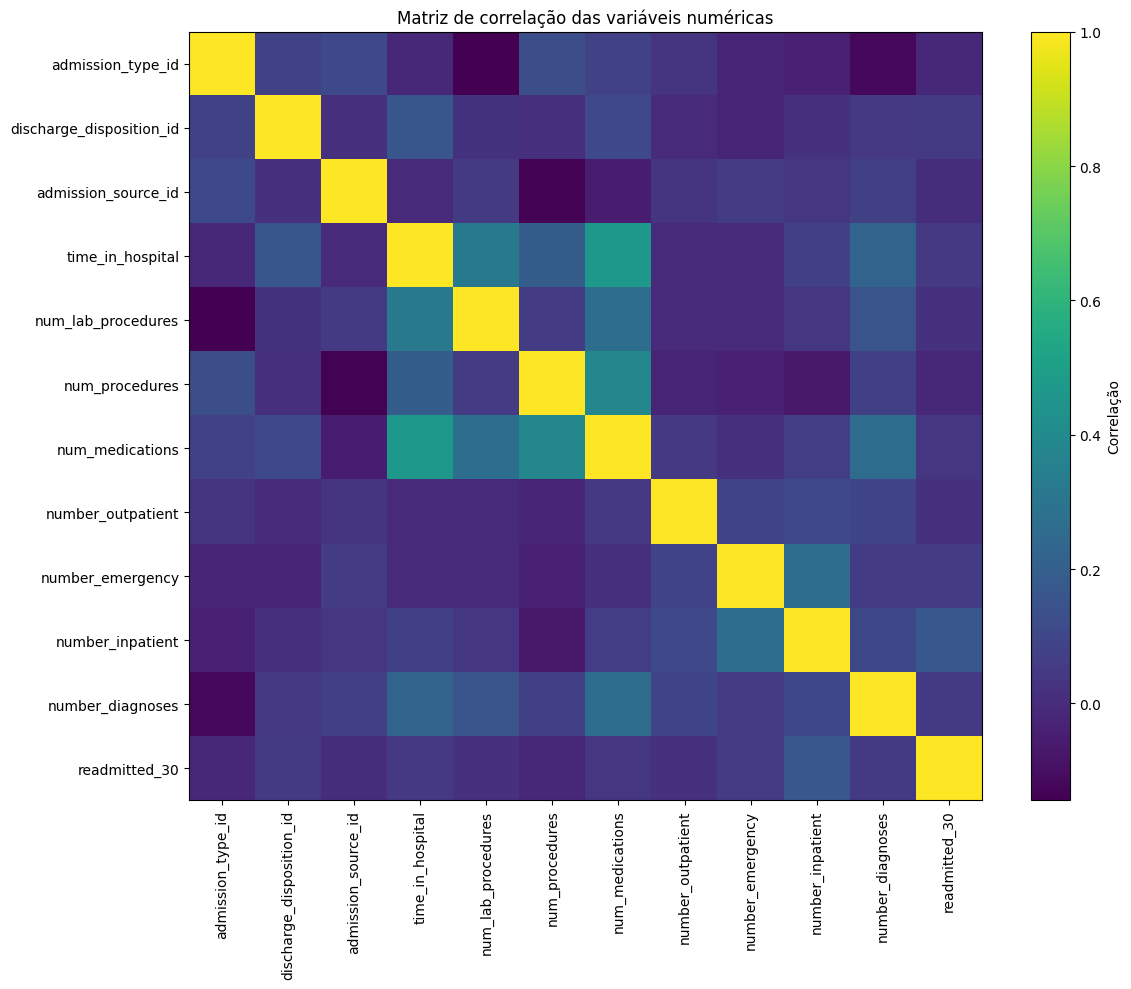

In [61]:
plt.figure(figsize=(12, 10))

plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlação")

plt.xticks(
    ticks=range(len(corr_matrix.columns)),
    labels=corr_matrix.columns,
    rotation=90
)

plt.yticks(
    ticks=range(len(corr_matrix.index)),
    labels=corr_matrix.index
)

plt.title("Matriz de correlação das variáveis numéricas")
plt.tight_layout()

plt.savefig("../outputs/figuras/matriz_correlacao_numericas.png", dpi=300, bbox_inches="tight")
plt.show()


In [62]:
corr_target = corr_matrix["readmitted_30"].sort_values(ascending=False)

corr_target

readmitted_30               1.000000
number_inpatient            0.165147
number_emergency            0.060747
discharge_disposition_id    0.050560
number_diagnoses            0.049524
time_in_hospital            0.044199
num_medications             0.038432
num_lab_procedures          0.020364
number_outpatient           0.018893
admission_source_id         0.005820
admission_type_id          -0.011651
num_procedures             -0.012227
Name: readmitted_30, dtype: float64

## 1.11 Análise de anomalias e valores extremos

Nesta etapa são analisados possíveis valores extremos nas variáveis numéricas. Em contexto clínico, valores extremos podem representar situações reais e relevantes, pelo que não devem ser removidos automaticamente sem justificação.

Foi utilizado o método do intervalo interquartil, IQR, como abordagem exploratória para identificar potenciais outliers.

In [64]:
outlier_summary = []

for col in numeric_vars:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    n_outliers = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    pct_outliers = n_outliers / len(df_clean) * 100
    
    outlier_summary.append({
        "variavel": col,
        "limite_inferior": lower_bound,
        "limite_superior": upper_bound,
        "n_outliers": n_outliers,
        "pct_outliers": pct_outliers
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,variavel,limite_inferior,limite_superior,n_outliers,pct_outliers
0,time_in_hospital,-4.0,12.0,2252,2.212920
1,num_lab_procedures,-8.0,96.0,143,0.140518
2,num_procedures,-3.0,5.0,4954,4.868031
3,num_medications,-5.0,35.0,2557,2.512627
4,number_outpatient,0.0,0.0,16739,16.448519
5,number_emergency,0.0,0.0,11383,11.185465
6,number_inpatient,-1.5,2.5,7049,6.926675
7,number_diagnoses,1.5,13.5,281,0.276124


## 1.12 Normalização e divisão treino/teste

As variáveis numéricas apresentam escalas diferentes. Por exemplo, `num_lab_procedures` pode atingir valores superiores a 100, enquanto `num_procedures` varia entre 0 e 6. Por esse motivo, a normalização será necessária na fase de modelação.

A normalização não será aplicada directamente a todo o conjunto de dados nesta fase, para evitar fuga de informação entre treino e teste. Em vez disso, será aplicada posteriormente dentro de um pipeline de pré-processamento, ajustado apenas ao conjunto de treino.

Nesta etapa, é realizada a divisão dos dados em conjunto de treino e conjunto de teste, mantendo a proporção da variável-alvo através de divisão estratificada.

In [65]:
from sklearn.model_selection import train_test_split

# Definir variável-alvo
target = "readmitted_30"

# Colunas a excluir das variáveis explicativas
cols_to_exclude = [
    "encounter_id",
    "patient_nbr",
    "readmitted",
    "readmitted_30"
]

X = df_clean.drop(columns=cols_to_exclude)
y = df_clean[target]

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

Dimensão de X: (101766, 44)
Dimensão de y: (101766,)


In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nDistribuição da variável-alvo no treino:")
display(y_train.value_counts(normalize=True) * 100)

print("\nDistribuição da variável-alvo no teste:")
display(y_test.value_counts(normalize=True) * 100)

X_train: (81412, 44)
X_test: (20354, 44)
y_train: (81412,)
y_test: (20354,)

Distribuição da variável-alvo no treino:


readmitted_30
0    88.839483
1    11.160517
Name: proportion, dtype: float64


Distribuição da variável-alvo no teste:


readmitted_30
0    88.842488
1    11.157512
Name: proportion, dtype: float64